# Task 5 — COVID-19 Public Health Data Dashboard

**Objective:** Extract public health data from open data portals and perform
exploratory data analysis and visualization of COVID-19 global statistics.

**API:** disease.sh — Open Disease Data API
- Completely free, no API key required
- Real-time and historical COVID-19 data for all countries
- Fields: cases, deaths, recovered, active, tests, population, vaccinations

**Data collected:**
- Global summary statistics (all countries combined)
- Per-country breakdown (all ~200 countries)
- Historical 90-day trend (global daily cases and deaths)
- Continental aggregations

**Pipeline:**
1. Fetch global summary, per-country data, and historical trends
2. Parse JSON into Pandas DataFrames
3. Clean and enrich the data
4. Perform exploratory data analysis
5. Build a comprehensive visualization dashboard

## 1. Import Libraries

In [1]:
# requests fetches data from the disease.sh API
import requests

# Pandas for storing, cleaning, and analyzing health data
import pandas as pd
import numpy as np

# datetime for parsing historical date keys
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Set global plot style
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#f8f9fa'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.3

print('All libraries imported successfully.')


All libraries imported successfully.


## 2. API Configuration

In [3]:
# ── disease.sh API endpoints ──────────────────────────────────────────────────
# disease.sh is a free open-source disease data API aggregating data from
# WHO, Johns Hopkins University, and government health portals worldwide.
BASE = 'https://disease.sh/v3/covid-19'

ENDPOINTS = {
    'global':      f'{BASE}/all',                          # Single global summary
    'countries':   f'{BASE}/countries',                    # All countries breakdown
    'continents':  f'{BASE}/continents',                   # Continental aggregation
    'historical':  f'{BASE}/historical/all?lastdays=90',   # 90-day global trend
}

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
    'Accept': 'application/json',
}

print('API endpoints configured:')
for name, url in ENDPOINTS.items():
    print(f'  {name}: {url}')


API endpoints configured:
  global: https://disease.sh/v3/covid-19/all
  countries: https://disease.sh/v3/covid-19/countries
  continents: https://disease.sh/v3/covid-19/continents
  historical: https://disease.sh/v3/covid-19/historical/all?lastdays=90


## 3. Fetch Data from API

In [6]:
def fetch_data(url: str, label: str) -> dict | list | None:
    """
    Sends a GET request to the disease.sh API and returns parsed JSON.
    Returns None if the request fails.
    """
    try:
        r = requests.get(url, headers=HEADERS, timeout=15)
        if r.status_code != 200:
            print(f'  [!] {label}: HTTP {r.status_code}')
            return None
        data = r.json()
        print(f'  {label}: OK — ', end='')
        if isinstance(data, list):
            print(f'{len(data)} records')
        elif isinstance(data, dict):
            print(f'{len(data)} fields')
        return data
    except Exception as e:
        print(f'  [!] {label}: Error — {e}')
        return None


print('Fetching data from disease.sh API...\n')

raw_global     = fetch_data(ENDPOINTS['global'],     'Global Summary')
raw_countries  = fetch_data(ENDPOINTS['countries'],  'Countries')
raw_continents = fetch_data(ENDPOINTS['continents'], 'Continents')
raw_historical = fetch_data(ENDPOINTS['historical'], 'Historical (90 days)')

print('\nAll data fetched successfully.')


Fetching data from disease.sh API...

  Global Summary: OK — 21 fields
  Countries: OK — 231 records
  Continents: OK — 6 records
  Historical (90 days): OK — 3 fields

All data fetched successfully.


## 4. Parse Data into DataFrames

In [8]:
# ── Global Summary ────────────────────────────────────────────────────────────
# Single dictionary with worldwide totals
global_stats = {
    'total_cases':     raw_global.get('cases', 0),
    'total_deaths':    raw_global.get('deaths', 0),
    'total_recovered': raw_global.get('recovered', 0),
    'active_cases':    raw_global.get('active', 0),
    'critical':        raw_global.get('critical', 0),
    'total_tests':     raw_global.get('tests', 0),
    'population':      raw_global.get('population', 0),
    'case_fatality_rate': round(raw_global.get('deaths', 0) / raw_global.get('cases', 1) * 100, 2),
    'recovery_rate':   round(raw_global.get('recovered', 0) / raw_global.get('cases', 1) * 100, 2),
}

print('GLOBAL COVID-19 SUMMARY:')
for k, v in global_stats.items():
    if isinstance(v, int):
        print(f'  {k:30}: {v:>20,}')
    else:
        print(f'  {k:30}: {v:>20}')


GLOBAL COVID-19 SUMMARY:
  total_cases                   :          704,753,890
  total_deaths                  :            7,010,681
  total_recovered               :          675,619,811
  active_cases                  :           22,123,398
  critical                      :               34,794
  total_tests                   :        7,026,505,313
  population                    :        7,944,935,131
  case_fatality_rate            :                 0.99
  recovery_rate                 :                95.87


In [10]:
# ── Countries DataFrame ───────────────────────────────────────────────────────
# Each country object contains nested fields — we flatten them.
countries_parsed = []

for c in raw_countries:
    countries_parsed.append({
        'country':          c.get('country', ''),
        'continent':        c.get('continent', ''),
        'population':       c.get('population', 0),
        'cases':            c.get('cases', 0),
        'deaths':           c.get('deaths', 0),
        'recovered':        c.get('recovered', 0),
        'active':           c.get('active', 0),
        'critical':         c.get('critical', 0),
        'tests':            c.get('tests', 0),
        'cases_per_1m':     c.get('casesPerOneMillion', 0),
        'deaths_per_1m':    c.get('deathsPerOneMillion', 0),
        'tests_per_1m':     c.get('testsPerOneMillion', 0),
        'today_cases':      c.get('todayCases', 0),
        'today_deaths':     c.get('todayDeaths', 0),
        'today_recovered':  c.get('todayRecovered', 0),
    })

df_countries = pd.DataFrame(countries_parsed)

print(f'Countries DataFrame shape: {df_countries.shape}')
print(f'Columns: {df_countries.columns.tolist()}')
df_countries.head()


Countries DataFrame shape: (231, 15)
Columns: ['country', 'continent', 'population', 'cases', 'deaths', 'recovered', 'active', 'critical', 'tests', 'cases_per_1m', 'deaths_per_1m', 'tests_per_1m', 'today_cases', 'today_deaths', 'today_recovered']


,country,continent,population,cases,deaths,recovered,active,critical,tests,cases_per_1m,deaths_per_1m,tests_per_1m,today_cases,today_deaths,today_recovered
0,Afghanistan,Asia,40754388,234174,7996,211080,15098,0,1390730,5746,196,34125,0,0,0
1,Albania,Europe,2866374,334863,3605,330233,1025,0,1941032,116825,1258,677173,0,0,0
2,Algeria,Africa,45350148,272010,6881,183061,82068,0,230960,5998,152,5093,0,0,0
3,Andorra,Europe,77463,48015,165,0,47850,0,249838,619844,2130,3225256,0,0,0
4,Angola,Africa,35027343,107327,1937,103419,1971,0,1499795,3064,55,42818,0,0,0


In [12]:
# ── Continents DataFrame ──────────────────────────────────────────────────────
continents_parsed = []
for c in raw_continents:
    continents_parsed.append({
        'continent':     c.get('continent', ''),
        'cases':         c.get('cases', 0),
        'deaths':        c.get('deaths', 0),
        'recovered':     c.get('recovered', 0),
        'active':        c.get('active', 0),
        'tests':         c.get('tests', 0),
        'population':    c.get('population', 0),
        'cases_per_1m':  c.get('casesPerOneMillion', 0),
        'deaths_per_1m': c.get('deathsPerOneMillion', 0),
    })

df_continents = pd.DataFrame(continents_parsed)
df_continents['case_fatality_rate'] = (df_continents['deaths'] / df_continents['cases'] * 100).round(2)

print(f'Continents: {df_continents["continent"].tolist()}')
df_continents


Continents: ['North America', 'Asia', 'Europe', 'South America', 'Australia-Oceania', 'Africa']


,continent,cases,deaths,recovered,active,tests,population,cases_per_1m,deaths_per_1m,case_fatality_rate
0,North America,131889132,1695941,127665129,2528062,1325710449,598140916,220498.43,2835.35,1.29
1,Asia,221500265,1553662,205673091,14273512,2404652039,4711356783,47014.11,329.77,0.70
2,Europe,253406198,2101824,248754104,2550270,2848046702,747543837,338985.07,2811.64,0.83
3,South America,70200879,1367332,66683585,2149962,245395353,437694443,160387.87,3123.94,1.95
4,Australia-Oceania,14895771,33015,14752388,110368,91668192,43470408,342664.62,759.48,0.22
5,Africa,12860924,258892,12090808,511224,111032578,1406728744,9142.43,184.04,2.01


In [14]:
# ── Historical Trend DataFrame ────────────────────────────────────────────────
# The historical endpoint returns:
# { 'cases': {'1/22/20': 555, '1/23/20': 654, ...},
#   'deaths': {'1/22/20': 17, ...},
#   'recovered': {...} }

hist_cases     = raw_historical.get('cases', {})
hist_deaths    = raw_historical.get('deaths', {})
hist_recovered = raw_historical.get('recovered', {})

df_historical = pd.DataFrame({
    'date':      pd.to_datetime(list(hist_cases.keys())),
    'cases':     list(hist_cases.values()),
    'deaths':    list(hist_deaths.values()),
    'recovered': list(hist_recovered.values()),
})

# Calculate daily new cases/deaths (difference from previous day)
df_historical = df_historical.sort_values('date').reset_index(drop=True)
df_historical['new_cases']  = df_historical['cases'].diff().clip(lower=0)
df_historical['new_deaths'] = df_historical['deaths'].diff().clip(lower=0)

# 7-day rolling average for smoother trend lines
df_historical['new_cases_7d']  = df_historical['new_cases'].rolling(7).mean()
df_historical['new_deaths_7d'] = df_historical['new_deaths'].rolling(7).mean()

print(f'Historical DataFrame shape: {df_historical.shape}')
print(f'Date range: {df_historical["date"].min().date()} → {df_historical["date"].max().date()}')
df_historical.tail(10)


Historical DataFrame shape: (90, 8)
Date range: 2022-12-10 → 2023-03-09


,date,cases,deaths,recovered,new_cases,new_deaths,new_cases_7d,new_deaths_7d
80,2023-02-28,675322238,6872682,0,150799.0,874.0,142645.285714,942.000000
81,2023-03-01,675542852,6874463,0,220614.0,1781.0,139004.000000,936.285714
82,2023-03-02,675731911,6876031,0,189059.0,1568.0,134427.857143,887.714286
83,2023-03-03,675914580,6877325,0,182669.0,1294.0,140176.857143,931.285714
84,2023-03-04,675968775,6877601,0,54195.0,276.0,141426.000000,939.571429
85,2023-03-05,676024901,6877749,0,56126.0,148.0,140069.571429,925.857143
86,2023-03-06,676082941,6878115,0,58040.0,366.0,130214.571429,901.000000
87,2023-03-07,676213378,6879038,0,130437.0,923.0,127305.714286,908.000000
88,2023-03-08,676392824,6880483,0,179446.0,1445.0,121424.571429,860.000000
89,2023-03-09,676570149,6881802,0,177325.0,1319.0,119748.285714,824.428571


## 5. Data Cleaning & Feature Engineering

In [17]:
# ── Clean countries DataFrame ─────────────────────────────────────────────────
# Remove rows with no country name or zero population
before = len(df_countries)
df_countries = df_countries[
    (df_countries['country'] != '') &
    (df_countries['population'] > 0) &
    (df_countries['cases'] > 0)
].copy()
print(f'Countries removed (no data): {before - len(df_countries)} | Remaining: {len(df_countries)}')


Countries removed (no data): 2 | Remaining: 229


In [19]:
# ── Add derived metrics ───────────────────────────────────────────────────────
# Case Fatality Rate: percentage of confirmed cases that resulted in death
df_countries['case_fatality_rate'] = (
    df_countries['deaths'] / df_countries['cases'] * 100
).round(2)

# Recovery Rate: percentage of confirmed cases that recovered
df_countries['recovery_rate'] = (
    df_countries['recovered'] / df_countries['cases'] * 100
).round(2)

# Cases as percentage of population
df_countries['cases_pct_population'] = (
    df_countries['cases'] / df_countries['population'] * 100
).round(2)

# Replace infinity and NaN values from division by zero
df_countries.replace([np.inf, -np.inf], np.nan, inplace=True)
df_countries.fillna(0, inplace=True)

print('Derived metrics added: case_fatality_rate, recovery_rate, cases_pct_population')
print(f'\nGlobal case fatality rate: {df_countries["deaths"].sum() / df_countries["cases"].sum() * 100:.2f}%')
print(f'Global recovery rate:      {df_countries["recovered"].sum() / df_countries["cases"].sum() * 100:.2f}%')


Derived metrics added: case_fatality_rate, recovery_rate, cases_pct_population

Global case fatality rate: 0.99%
Global recovery rate:      79.54%


## 6. Exploratory Data Analysis

In [22]:
# ── Top 10 countries by total cases ──────────────────────────────────────────
top_cases = df_countries.nlargest(10, 'cases')[['country', 'cases', 'deaths', 'recovered', 'case_fatality_rate']]
print('TOP 10 COUNTRIES BY TOTAL CASES:')
print(top_cases.to_string(index=False))


TOP 10 COUNTRIES BY TOTAL CASES:
 country     cases  deaths  recovered  case_fatality_rate
     USA 111820082 1219487  109814428                1.09
   India  45035393  533570          0                1.18
  France  40138560  167642   39970918                0.42
 Germany  38828995  183027   38240600                0.47
  Brazil  38743918  711380   36249161                1.84
S. Korea  34571873   35934   34535939                0.10
   Japan  33803572   74694          0                0.22
   Italy  26723249  196487   26361218                0.74
      UK  24910387  232112   24678275                0.93
  Russia  24124215  402756   23545818                1.67


In [24]:
# ── Top 10 countries by cases per million population ─────────────────────────
# This is more meaningful than raw cases as it accounts for country size
top_per_million = df_countries.nlargest(10, 'cases_per_1m')[['country', 'population', 'cases', 'cases_per_1m', 'deaths_per_1m']]
print('TOP 10 COUNTRIES BY CASES PER MILLION POPULATION:')
print(top_per_million.to_string(index=False))


TOP 10 COUNTRIES BY CASES PER MILLION POPULATION:
      country  population    cases  cases_per_1m  deaths_per_1m
       Brunei      445431   343719        771655            505
   San Marino       34085    26185        768226           3755
Faroe Islands       49233    34658        703959            569
     S. Korea    51329899 34571873        673523            700
      Austria     9066710  6081287        670727           2486
         Niue        1622     1059        652898              0
     Slovenia     2078034  1356546        652803           3417
      Andorra       77463    48015        619844           2130
   Martinique      374087   230354        615777           2946
       France    65584518 40138560        612013           2556


In [26]:
# ── Continental summary ───────────────────────────────────────────────────────
print('COVID-19 BY CONTINENT:')
print(df_continents[['continent', 'cases', 'deaths', 'recovered', 'case_fatality_rate', 'cases_per_1m']]
      .sort_values('cases', ascending=False)
      .to_string(index=False))


COVID-19 BY CONTINENT:
        continent     cases  deaths  recovered  case_fatality_rate  cases_per_1m
           Europe 253406198 2101824  248754104                0.83     338985.07
             Asia 221500265 1553662  205673091                0.70      47014.11
    North America 131889132 1695941  127665129                1.29     220498.43
    South America  70200879 1367332   66683585                1.95     160387.87
Australia-Oceania  14895771   33015   14752388                0.22     342664.62
           Africa  12860924  258892   12090808                2.01       9142.43


In [28]:
# ── Poland specific stats ─────────────────────────────────────────────────────
poland = df_countries[df_countries['country'] == 'Poland']
if not poland.empty:
    print('POLAND COVID-19 STATISTICS:')
    for col in ['cases', 'deaths', 'recovered', 'active', 'tests',
                'cases_per_1m', 'deaths_per_1m', 'case_fatality_rate', 'recovery_rate']:
        val = poland[col].values[0]
        print(f'  {col:30}: {val:>15,}' if isinstance(val, (int, float)) and val > 100 else f'  {col:30}: {val}')


POLAND COVID-19 STATISTICS:
  cases                         : 6661991
  deaths                        : 120598
  recovered                     : 0
  active                        : 6541393
  tests                         : 39323709
  cases_per_1m                  : 176524
  deaths_per_1m                 : 3196
  case_fatality_rate            : 1.81
  recovery_rate                 : 0.0


## 7. Visualization Dashboard

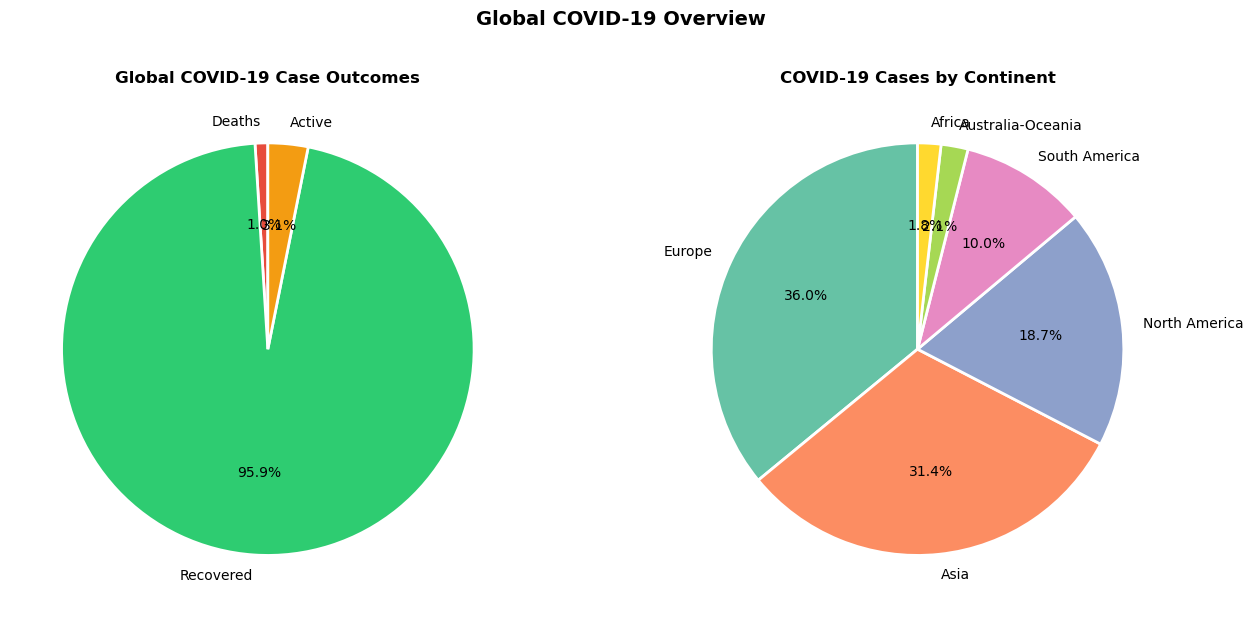

In [30]:
# ── Plot 1: Global Cases vs Deaths vs Recovered (Pie Charts) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left pie: outcome breakdown
labels_outcome = ['Deaths', 'Recovered', 'Active']
values_outcome = [
    global_stats['total_deaths'],
    global_stats['total_recovered'],
    global_stats['active_cases']
]
colors_outcome = ['#e74c3c', '#2ecc71', '#f39c12']
axes[0].pie(
    values_outcome, labels=labels_outcome, autopct='%1.1f%%',
    colors=colors_outcome, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Global COVID-19 Case Outcomes', fontsize=12, fontweight='bold')

# Right pie: continental case share
cont_sorted = df_continents.sort_values('cases', ascending=False)
axes[1].pie(
    cont_sorted['cases'], labels=cont_sorted['continent'],
    autopct='%1.1f%%', startangle=90,
    colors=sns.color_palette('Set2', len(cont_sorted)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('COVID-19 Cases by Continent', fontsize=12, fontweight='bold')

plt.suptitle('Global COVID-19 Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot1_global_overview.png', dpi=150, bbox_inches='tight')
plt.show()


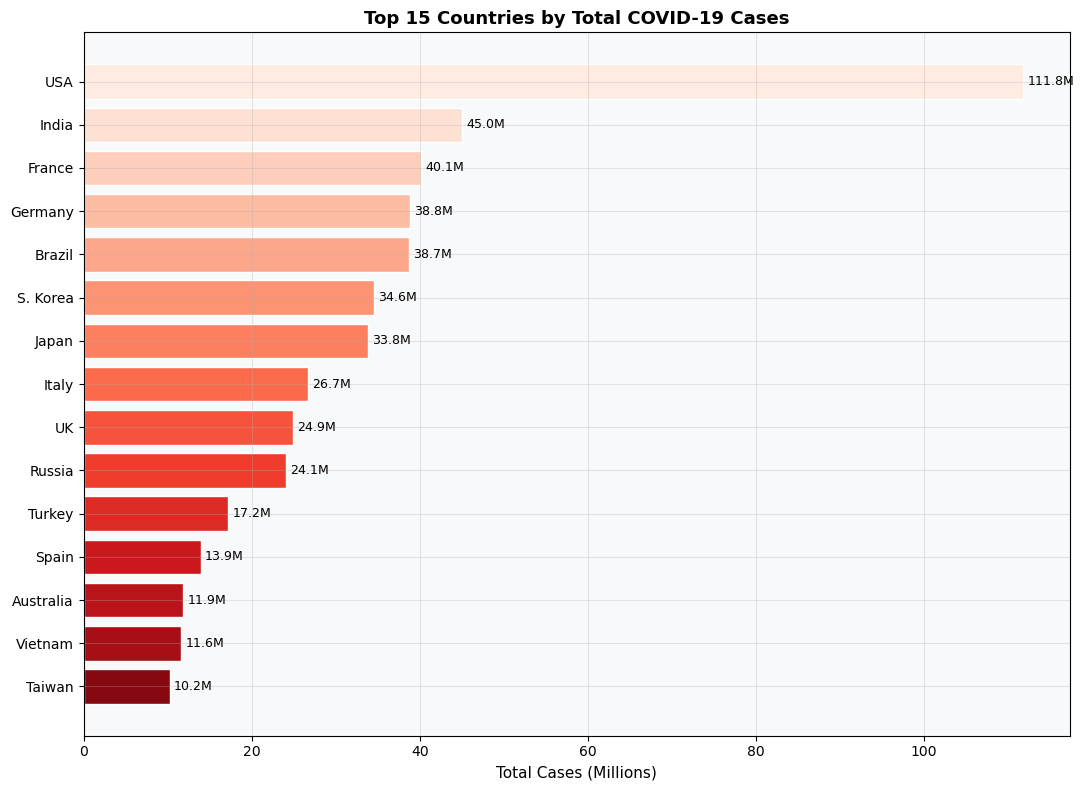

In [32]:
# ── Plot 2: Top 15 Countries by Total Cases ───────────────────────────────────
top15 = df_countries.nlargest(15, 'cases').sort_values('cases')

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(
    top15['country'], top15['cases'] / 1e6,
    color=sns.color_palette('Reds_r', len(top15)), edgecolor='white'
)
for bar, val in zip(bars, top15['cases'] / 1e6):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}M', va='center', fontsize=9)

ax.set_xlabel('Total Cases (Millions)', fontsize=11)
ax.set_title('Top 15 Countries by Total COVID-19 Cases',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_top_countries_cases.png', dpi=150, bbox_inches='tight')
plt.show()


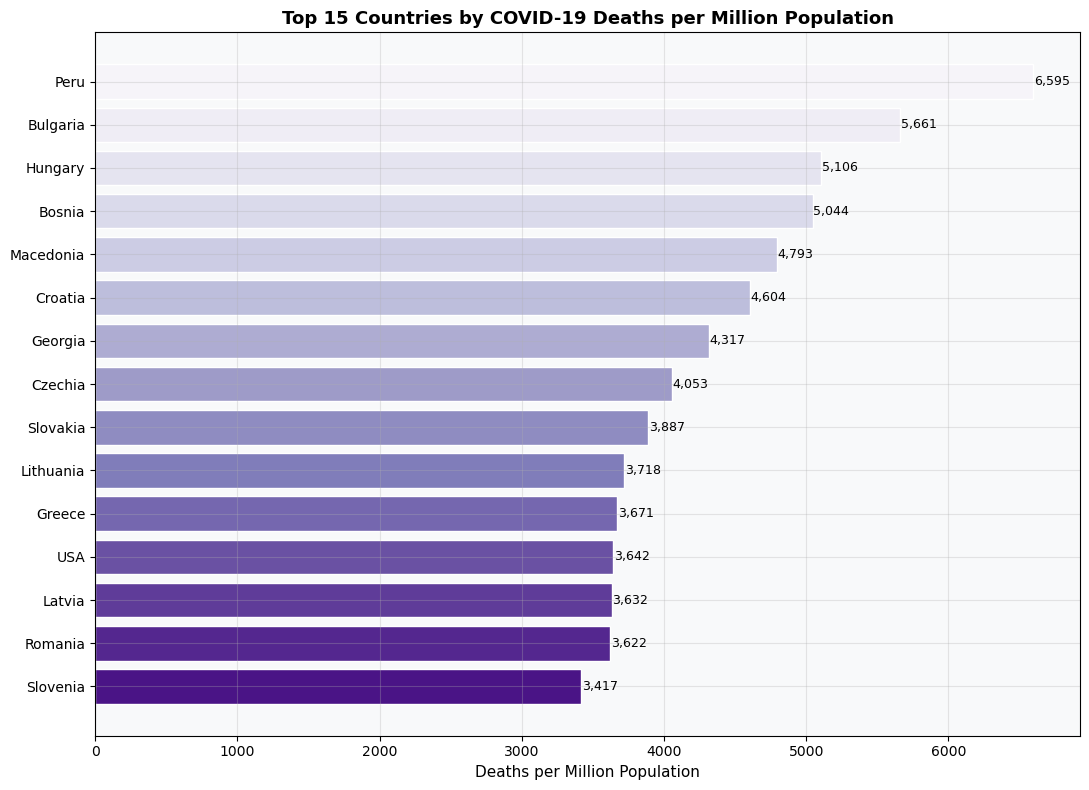

In [34]:
# ── Plot 3: Top 15 Countries by Deaths per Million ────────────────────────────
# Deaths per million is a fairer metric than raw deaths
# as it accounts for population size differences between countries
top15_deaths = df_countries[df_countries['population'] > 1000000].nlargest(15, 'deaths_per_1m').sort_values('deaths_per_1m')

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(
    top15_deaths['country'], top15_deaths['deaths_per_1m'],
    color=sns.color_palette('Purples_r', len(top15_deaths)), edgecolor='white'
)
for bar, val in zip(bars, top15_deaths['deaths_per_1m']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', fontsize=9)

ax.set_xlabel('Deaths per Million Population', fontsize=11)
ax.set_title('Top 15 Countries by COVID-19 Deaths per Million Population',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_deaths_per_million.png', dpi=150, bbox_inches='tight')
plt.show()


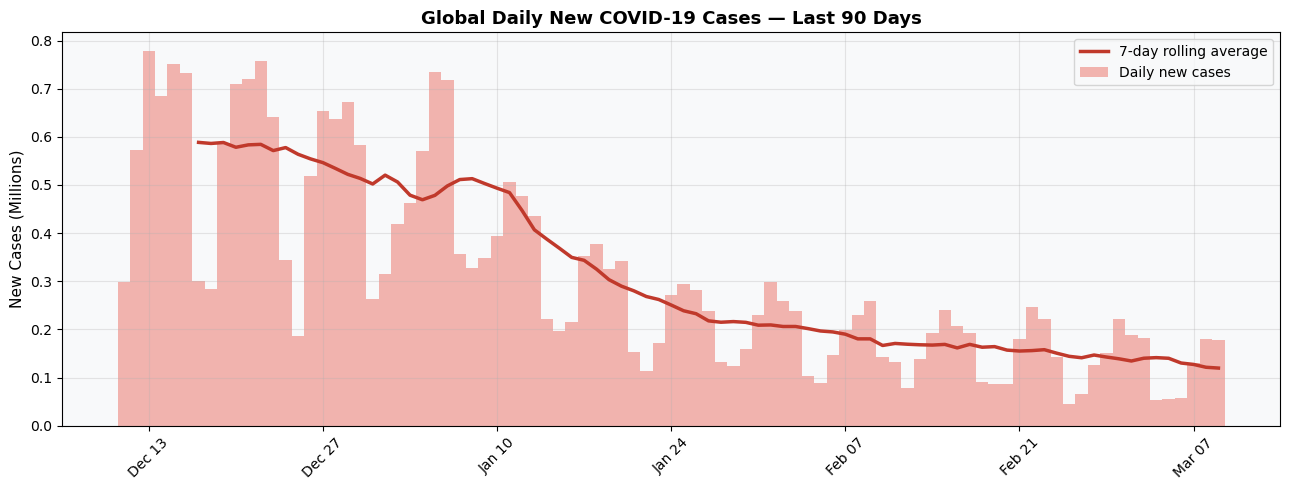

In [36]:
# ── Plot 4: Historical Daily New Cases + 7-Day Average ────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

# Daily bars
ax.bar(
    df_historical['date'], df_historical['new_cases'] / 1e6,
    color='#e74c3c', alpha=0.4, width=1, label='Daily new cases'
)
# 7-day rolling average line
ax.plot(
    df_historical['date'], df_historical['new_cases_7d'] / 1e6,
    color='#c0392b', linewidth=2.5, label='7-day rolling average'
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.set_ylabel('New Cases (Millions)', fontsize=11)
ax.set_title('Global Daily New COVID-19 Cases — Last 90 Days',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plot4_daily_cases_trend.png', dpi=150, bbox_inches='tight')
plt.show()


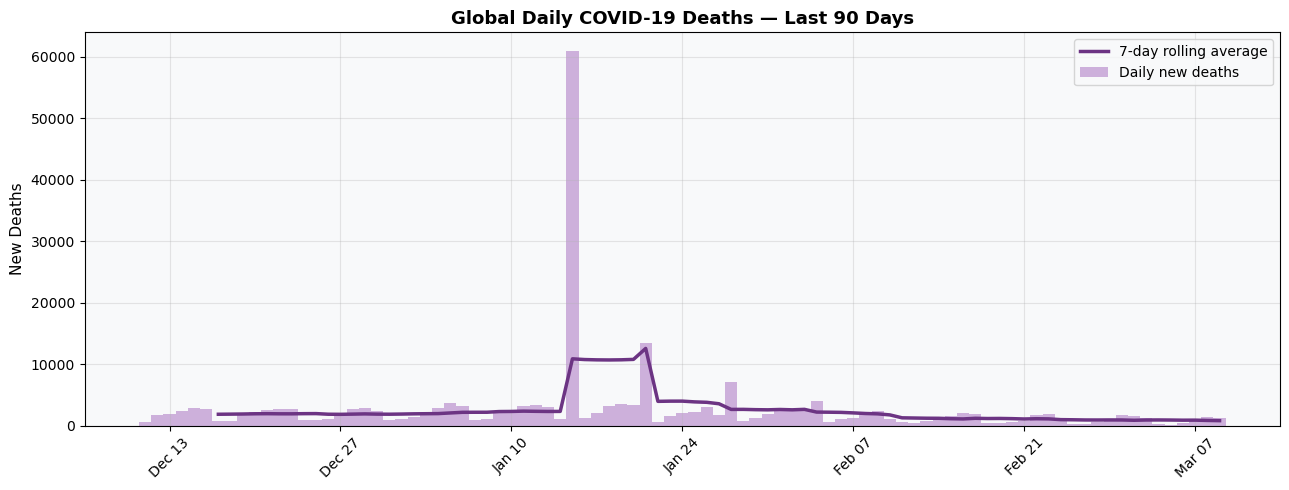

In [38]:
# ── Plot 5: Historical Daily Deaths + 7-Day Average ──────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(
    df_historical['date'], df_historical['new_deaths'],
    color='#8e44ad', alpha=0.4, width=1, label='Daily new deaths'
)
ax.plot(
    df_historical['date'], df_historical['new_deaths_7d'],
    color='#6c3483', linewidth=2.5, label='7-day rolling average'
)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.set_ylabel('New Deaths', fontsize=11)
ax.set_title('Global Daily COVID-19 Deaths — Last 90 Days',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plot5_daily_deaths_trend.png', dpi=150, bbox_inches='tight')
plt.show()


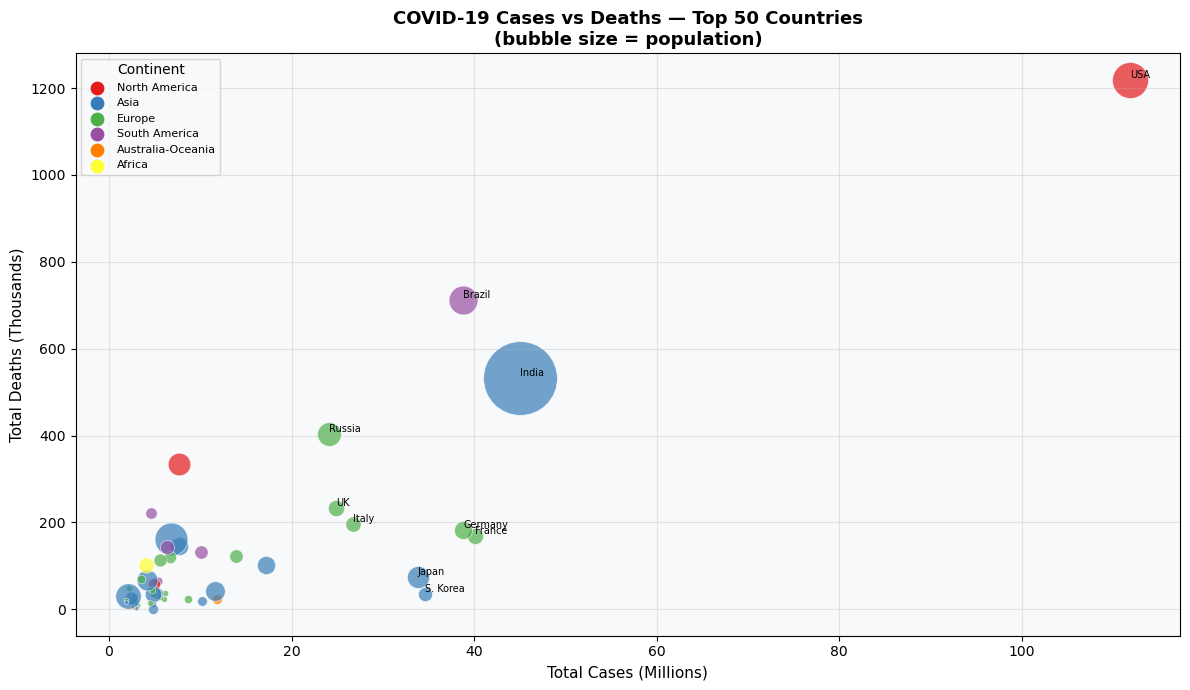

In [40]:
# ── Plot 6: Cases vs Deaths Scatter (Top 50 countries) ───────────────────────
# Bubble chart — bubble size = population, color = continent
top50 = df_countries.nlargest(50, 'cases')

fig, ax = plt.subplots(figsize=(12, 7))

continents = top50['continent'].unique()
colors = sns.color_palette('Set1', len(continents))
color_map = dict(zip(continents, colors))

for _, row in top50.iterrows():
    ax.scatter(
        row['cases'] / 1e6,
        row['deaths'] / 1e3,
        s=row['population'] / 5e5,   # Bubble size proportional to population
        color=color_map.get(row['continent'], 'gray'),
        alpha=0.7, edgecolors='white', linewidth=0.5
    )
    # Label the top 10 countries
    if row['cases'] > top50['cases'].quantile(0.8):
        ax.annotate(row['country'], (row['cases']/1e6, row['deaths']/1e3),
                    fontsize=7, ha='left', va='bottom')

# Add legend for continents
for cont, color in color_map.items():
    ax.scatter([], [], color=color, label=cont, s=80)
ax.legend(title='Continent', fontsize=8, loc='upper left')

ax.set_xlabel('Total Cases (Millions)', fontsize=11)
ax.set_ylabel('Total Deaths (Thousands)', fontsize=11)
ax.set_title('COVID-19 Cases vs Deaths — Top 50 Countries\n(bubble size = population)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot6_cases_vs_deaths_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


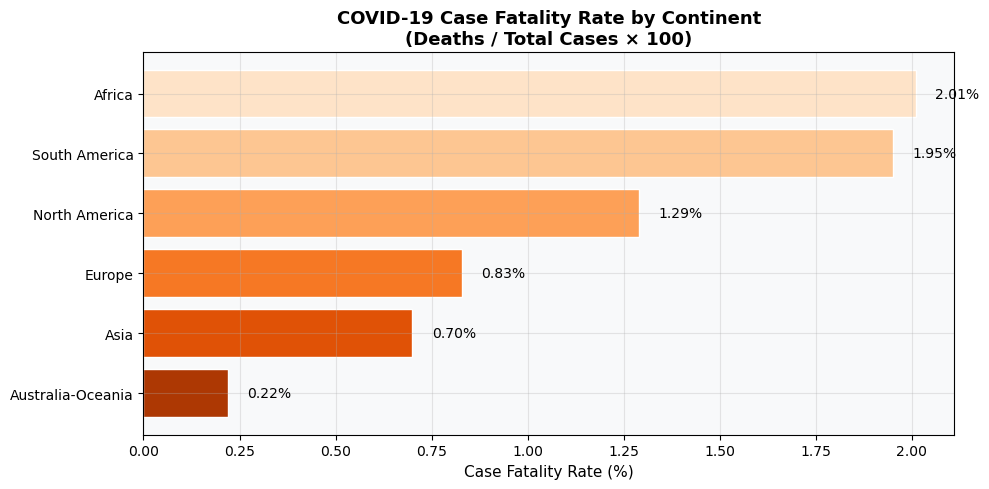

In [42]:
# ── Plot 7: Case Fatality Rate by Continent ───────────────────────────────────
cfr_sorted = df_continents.sort_values('case_fatality_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    cfr_sorted['continent'], cfr_sorted['case_fatality_rate'],
    color=sns.color_palette('Oranges_r', len(cfr_sorted)), edgecolor='white'
)
for bar, val in zip(bars, cfr_sorted['case_fatality_rate']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=10)

ax.set_xlabel('Case Fatality Rate (%)', fontsize=11)
ax.set_title('COVID-19 Case Fatality Rate by Continent\n(Deaths / Total Cases × 100)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot7_cfr_by_continent.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Export Results

In [44]:
# ── Save all DataFrames to CSV ────────────────────────────────────────────────
df_countries.to_csv('covid_countries.csv', index=False, encoding='utf-8-sig')
print('Saved: covid_countries.csv')

df_continents.to_csv('covid_continents.csv', index=False)
print('Saved: covid_continents.csv')

df_historical.to_csv('covid_historical_90days.csv', index=False)
print('Saved: covid_historical_90days.csv')

print('\n' + '='*55)
print('FINAL SUMMARY')
print('='*55)
print(f'  Countries analyzed:          {len(df_countries)}')
print(f'  Global total cases:          {global_stats["total_cases"]:>15,}')
print(f'  Global total deaths:         {global_stats["total_deaths"]:>15,}')
print(f'  Global total recovered:      {global_stats["total_recovered"]:>15,}')
print(f'  Global case fatality rate:   {global_stats["case_fatality_rate"]:>14}%')
print(f'  Global recovery rate:        {global_stats["recovery_rate"]:>14}%')
print(f'  Most affected country:       {df_countries.nlargest(1, "cases")["country"].values[0]}')
print(f'  Historical data days:        {len(df_historical)}')
print('='*55)


Saved: covid_countries.csv
Saved: covid_continents.csv
Saved: covid_historical_90days.csv

FINAL SUMMARY
  Countries analyzed:          229
  Global total cases:              704,753,890
  Global total deaths:               7,010,681
  Global total recovered:          675,619,811
  Global case fatality rate:             0.99%
  Global recovery rate:                 95.87%
  Most affected country:       USA
  Historical data days:        90
